📖 [01a] PHÂN TÍCH KHÁM PHÁ DỮ LIỆU - PIMA INDIANS DIABETES

Mục tiêu: Thực hiện Phân tích Khám phá Dữ liệu (EDA) trên bộ dữ liệu Pima Indians Diabetes.

Các bước chính:
1. Tải và kiểm tra dữ liệu.
2. Thực hiện thống kê mô tả: Min/Max, Mean, Median.
3. Phân tích biến mục tiêu (Outcome) để kiểm tra mất cân bằng.
4. Trực quan hóa phân phối của từng thuộc tính (Histogram, Boxplot) để tìm giá trị "phổ biến/hiếm".
5. Phân tích tương quan giữa các thuộc tính (Heatmap).
6. Tổng hợp các phát hiện chính và đề xuất các bước tiền xử lý cần thiết.

1. TẢI THƯ VIỆN VÀ DỮ LIỆU

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt mặc định cho các biểu đồ
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [12]:
# Tải dữ liệu
file_path = "../../datasets/raw/diabetes_structured_final.csv"

try:
    df = pd.read_csv(file_path)
    print("Dữ liệu đã được tải thành công.")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file tại '{file_path}'.")
    print("Vui lòng kiểm tra lại đường dẫn và tên file. Bạn có thể cần tải dataset Pima Indians vào thư mục 'datasets/raw/'.")
    df = pd.DataFrame() # Tạo dataframe rỗng để tránh lỗi ở các cell sau

Dữ liệu đã được tải thành công.


1.1. KIỂM TRA TỔNG QUAN

In [13]:
# Hiển thị 5 dòng đầu tiên
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
# Kiểm tra thông tin các cột, kiểu dữ liệu và giá trị null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1268 non-null   int64  
 1   Glucose                   1268 non-null   int64  
 2   BloodPressure             1268 non-null   int64  
 3   SkinThickness             1268 non-null   int64  
 4   Insulin                   1268 non-null   int64  
 5   BMI                       1268 non-null   float64
 6   DiabetesPedigreeFunction  1268 non-null   float64
 7   Age                       1268 non-null   int64  
 8   Outcome                   1268 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 89.3 KB


Nhận xét:
- Dữ liệu có 768 dòng và 9 cột.
- Tất cả các cột đều là kiểu số (int64 hoặc float64).
- Không có giá trị null nào được ghi nhận. Tuy nhiên, chúng ta cần kiểm tra các giá trị bất thường (như số 0).

2. THỐNG KÊ MÔ TẢ

In [15]:
# Thực hiện df.describe() để lấy các giá trị thống kê quan trọng
stats_desc = df.describe()
stats_desc

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1268.000000,1268.000000,1268.000000,1268.000000,1268.000000,1268.000000,1268.000000,1268.000000,1268.000000
mean,3.780757,121.219243,68.570978,20.708202,83.727918,31.676577,0.474893,33.471609,0.350158
std,3.233244,33.041901,19.506917,15.883903,118.596013,7.958422,0.335342,11.860608,0.477207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,26.900000,0.244750,24.000000,0.000000
50%,3.000000,117.000000,70.000000,23.000000,44.000000,32.000000,0.377000,29.000000,0.000000
75%,6.000000,143.000000,80.000000,33.000000,130.000000,36.100000,0.631000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Bảng trên đã cung cấp đầy đủ các thông tin theo yêu cầu:
- mean: Giá trị trung bình
- min: Giá trị thấp nhất
- max: Giá trị cao nhất
- 50% (Median): Giá trị trung vị

⚠️ PHÁT HIỆN QUAN TRỌNG TỪ THỐNG KÊ MÔ TẢ
Nhìn vào hàng min (Giá trị thấp nhất), chúng ta phát hiện nhiều điểm bất thường nghiêm trọng:
- Glucose: min = 0
- BloodPressure: min = 0
- SkinThickness: min = 0
- Insulin: min = 0
- BMI: min = 0

* Lý do: Đây là các chỉ số y tế, chúng không thể bằng 0. Một người sống không thể có Nồng độ Glucose, Huyết áp, hay BMI bằng 0.

=> Kết luận: Các giá trị 0 này thực chất là dữ liệu bị thiếu (missing data) được mã hóa bằng số 0.

3. PHÂN TÍCH BIẾN MỤC TIÊU (Outcome)

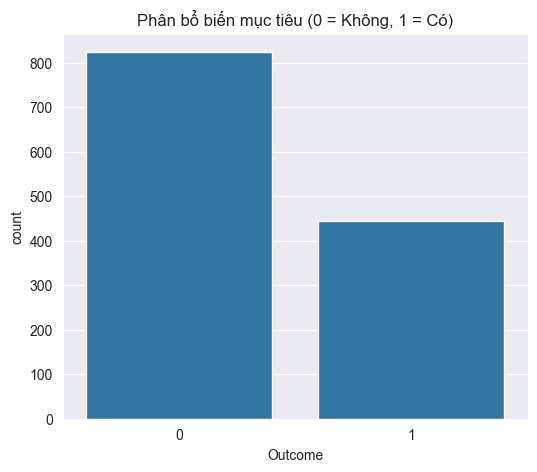

In [16]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Outcome', data=df)
plt.title('Phân bổ biến mục tiêu (0 = Không, 1 = Có)')
plt.show()

In [17]:
# Xem tỉ lệ phần trăm
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    64.984227
1    35.015773
Name: proportion, dtype: float64

Nhận xét:
- Dữ liệu bị mất cân bằng (imbalanced).
- Khoảng 65.1% là nhãn 0 (Không mắc bệnh) và 34.9% là nhãn 1 (Có mắc bệnh).
- Điều này cần được lưu ý khi chia tập train/test và khi đánh giá mô hình (không nên chỉ dùng Accuracy).

4. PHÂN TÍCH PHÂN PHỐI DỮ LIỆU (Tìm giá trị "Phổ biến/Hiếm")
Chúng ta sẽ vẽ biểu đồ Histogram (phân phối) và Boxplot (ngoại lai) cho các thuộc tính số.

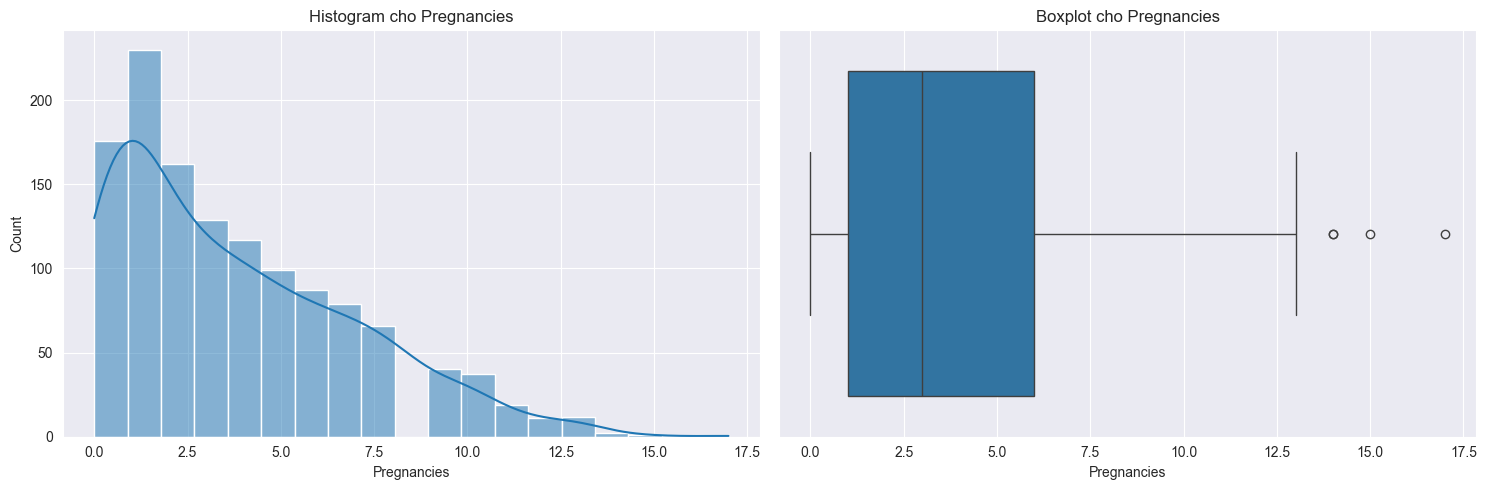

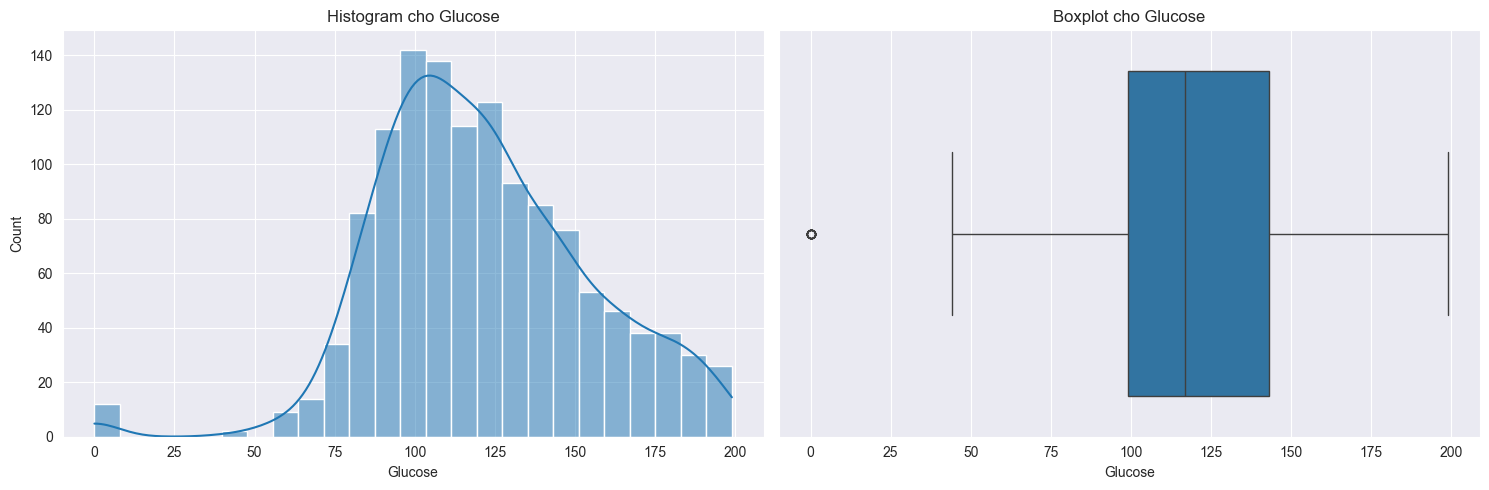

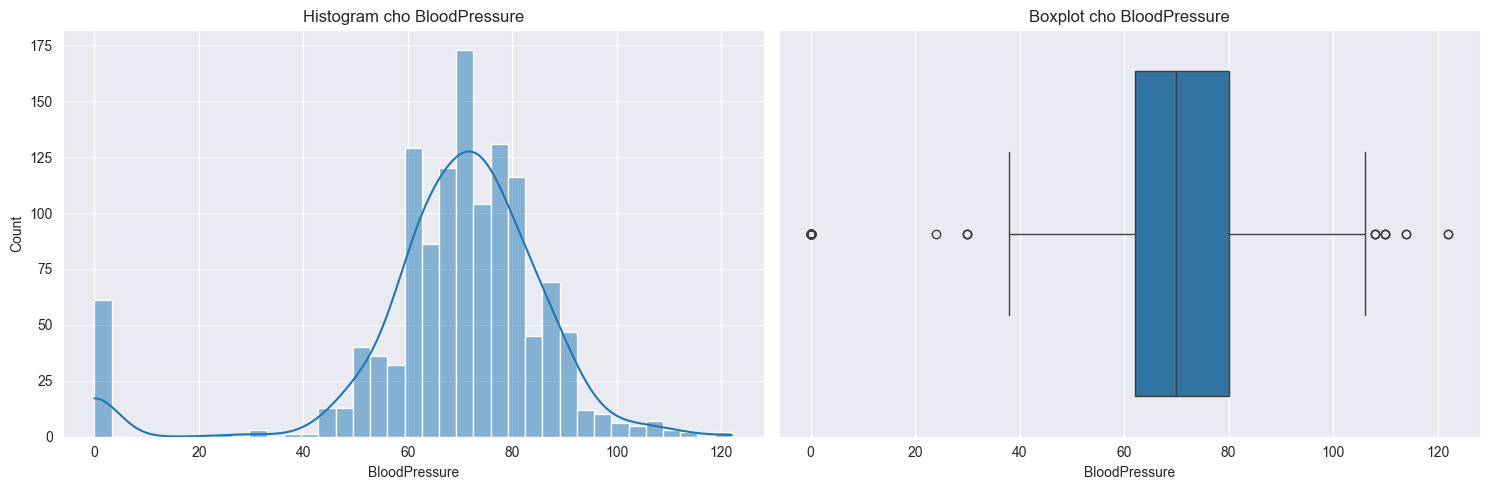

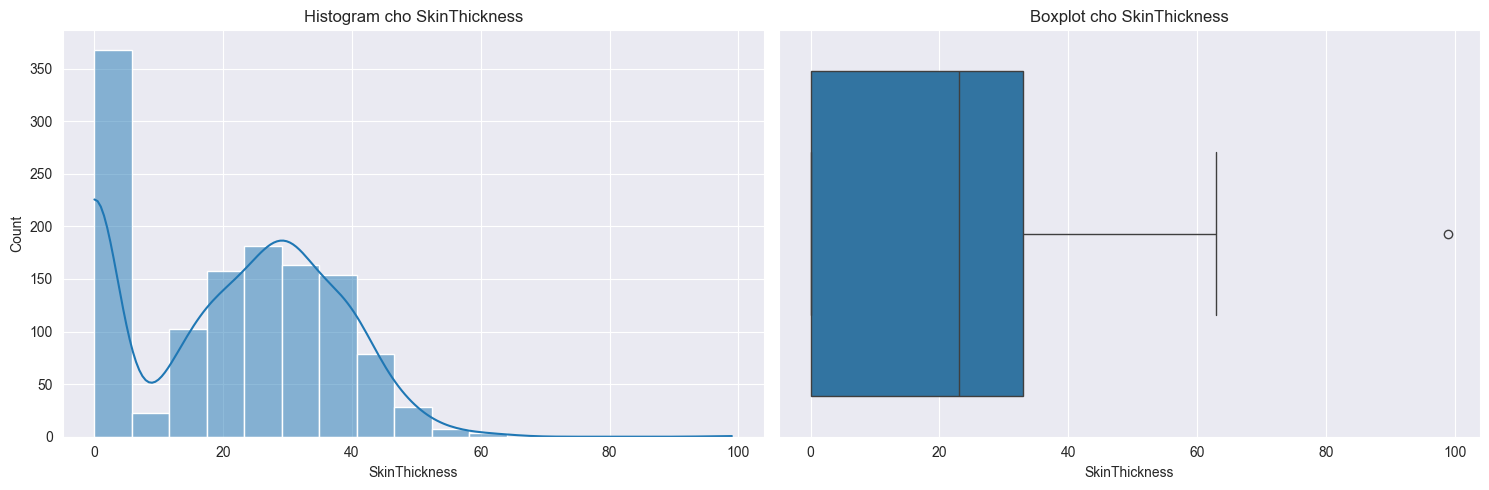

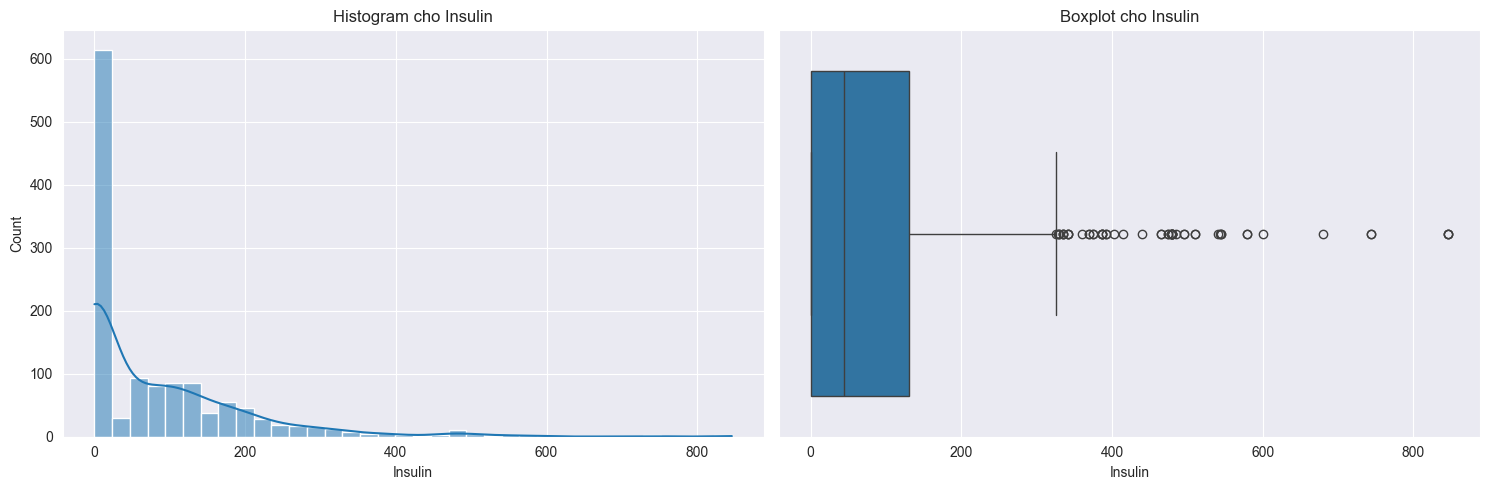

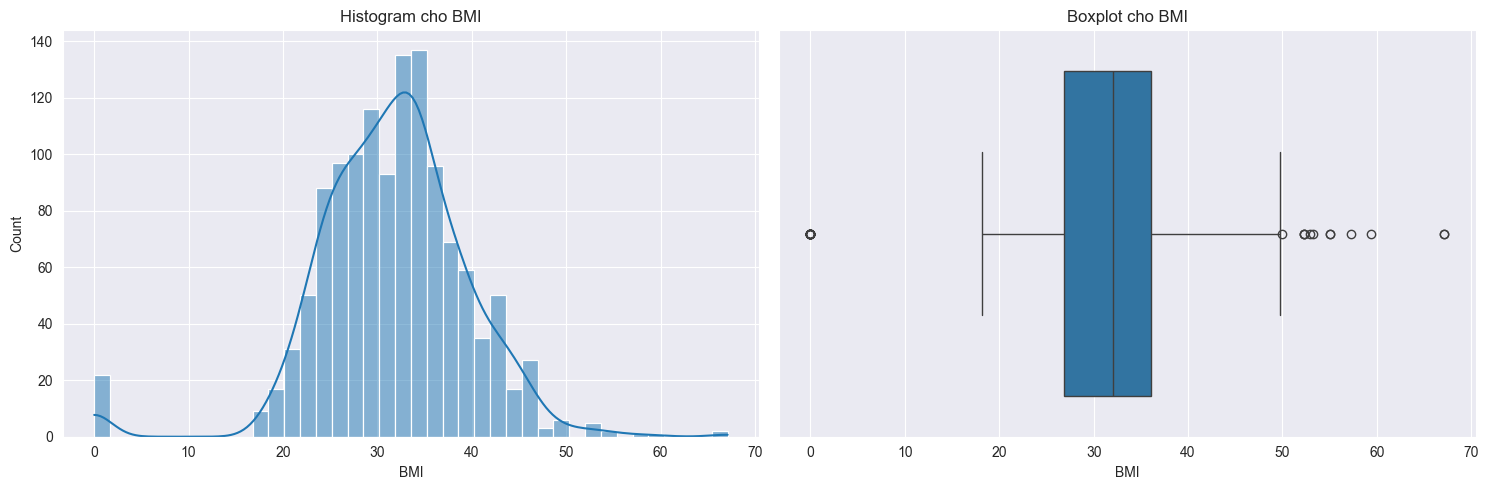

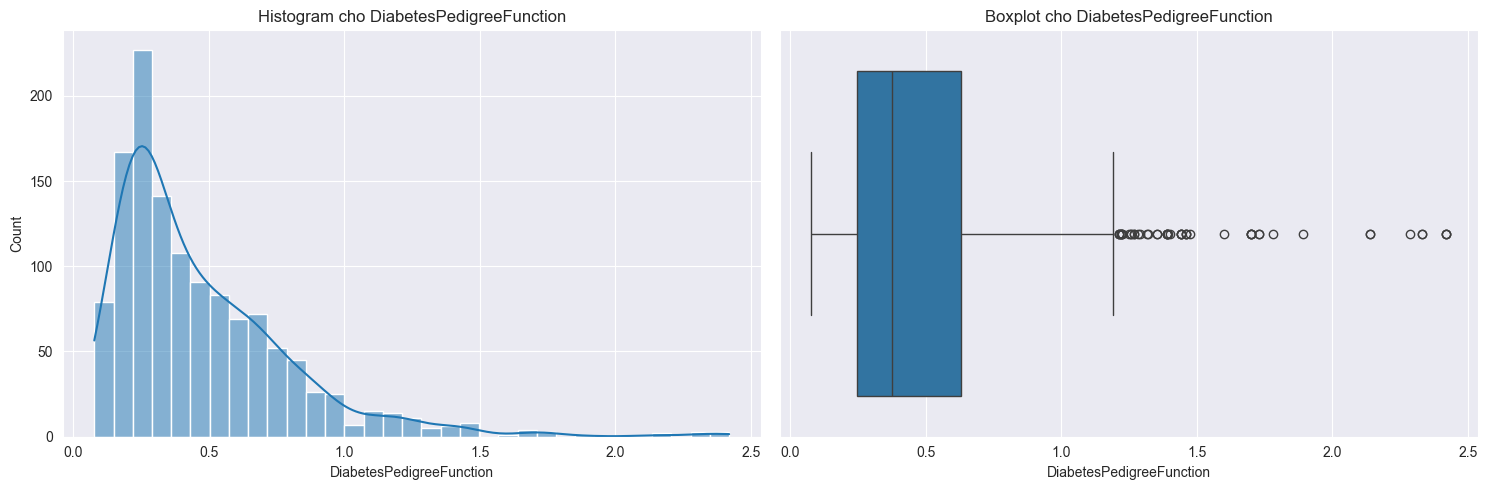

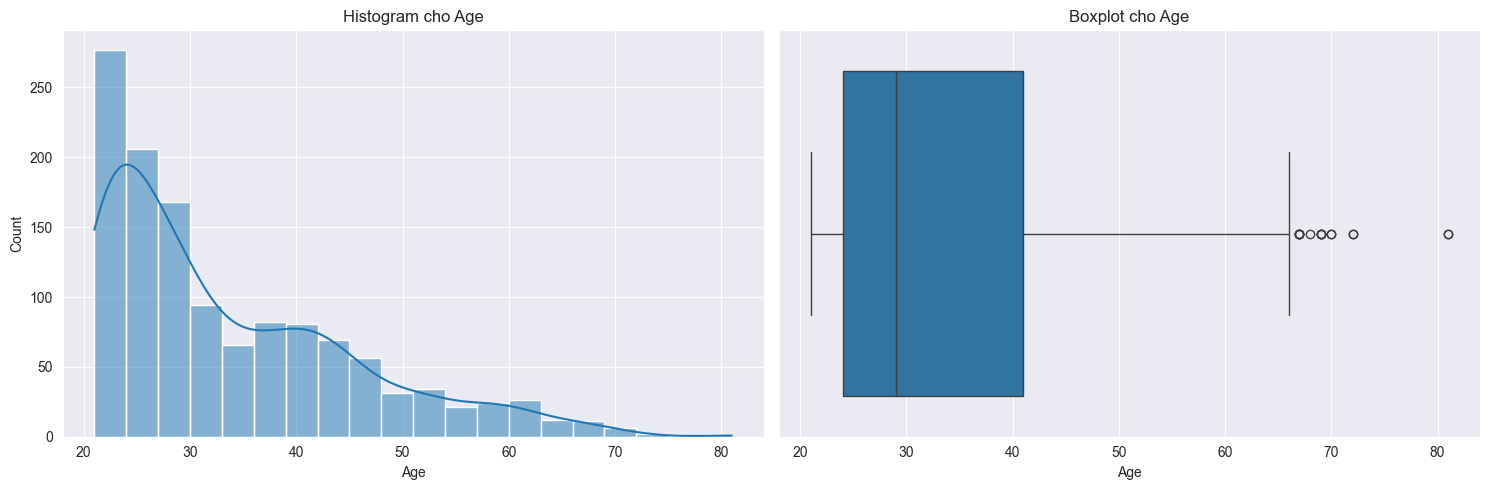

In [18]:
# Lấy danh sách các cột (trừ cột Outcome)
features = df.columns.drop('Outcome')

for feature in features:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram
    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram cho {feature}')
    
    # Boxplot
    sns.boxplot(x=df[feature], ax=axes[1])
    axes[1].set_title(f'Boxplot cho {feature}')
    
    plt.tight_layout()
    plt.show()

Nhận xét từ biểu đồ:
- Pregnancies: Giá trị phổ biến nhất là 0-1 lần mang thai. Dữ liệu lệch phải.
- Glucose: Phân phối khá chuẩn (gần giống hình chuông), nhưng bị ảnh hưởng bởi các giá trị 0 bất thường.
- BloodPressure: Tương tự Glucose, phân phối khá chuẩn nếu loại bỏ các giá trị 0.
- SkinThickness: Lệch phải, và có một lượng lớn giá trị 0.
- Insulin: Lệch phải rất mạnh. Đa số giá trị là 0 (bất thường). Có nhiều giá trị ngoại lai (outliers) rất lớn.
- BMI: Phân phối khá chuẩn, nhưng cũng bị ảnh hưởng bởi giá trị 0.
- DiabetesPedigreeFunction: Lệch phải mạnh.
- Age: Lệch phải. Giá trị phổ biến nhất là ở nhóm 20-30 tuổi.

5. PHÂN TÍCH TƯƠNG QUAN (CORRELATION)

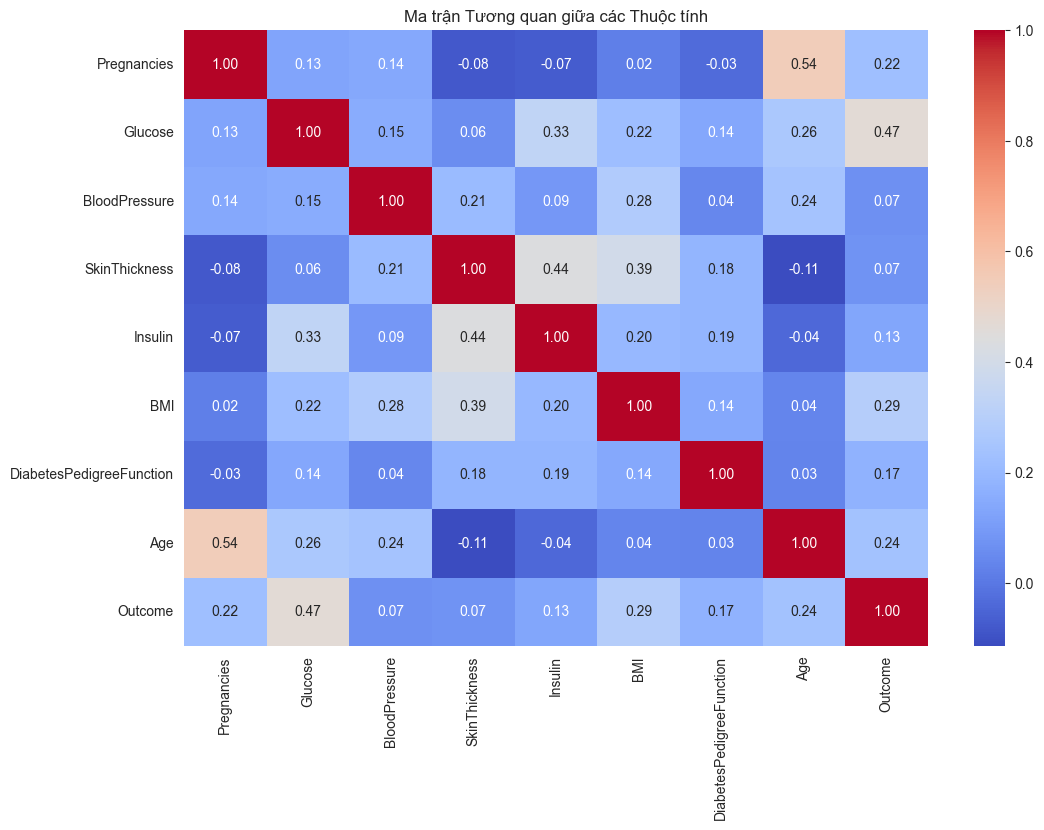

In [9]:
# Tính toán ma trận tương quan
corr_matrix = df.corr()

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận Tương quan giữa các Thuộc tính')
plt.show()

📝 Tổng kết các phát hiện (EDA)
Dựa trên phân tích trên, đây là các phát hiện chính sẽ ảnh hưởng trực tiếp đến bước Tiền xử lý và Mô hình hóa:
  1. Vấn đề dữ liệu "bẩn" (nghiêm trọng): Các cột Glucose, BloodPressure, SkinThickness, Insulin, và BMI chứa các giá trị 0 không hợp lệ, thực chất đây là dữ liệu bị thiếu.
  2. Mất cân bằng dữ liệu: Biến mục tiêu Outcome bị mất cân bằng (65% là 0, 35% là 1). Cần sử dụng các độ đo như Precision, Recall, F1-score thay vì chỉ Accuracy, và có thể cần áp dụng kỹ thuật (ví dụ: SMOTE) trong khi huấn luyện.
  3. Phân phối lệch (Skewness): Nhiều thuộc tính bị lệch (ví dụ: Insulin, DiabetesPedigreeFunction, Age). Các mô hình như Logistic Regression có thể hoạt động tốt hơn nếu dữ liệu này được chuẩn hóa.
  4. Các thuộc tính quan trọng: Glucose, BMI, và Age là các thuộc tính có vẻ quan trọng nhất để dự đoán Outcome.

➡️ Chuyển sang file 02_Preprocessing.ipynb để giải quyết các vấn đề này.